In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



In [2]:
df = pd.read_csv("Data/used_cars_data.csv", nrows=10_000)

In [4]:
df = df[df["bed"].isna()]
df = df[df["cabin"].isna()]
df = df[df["frame_damaged"] != True]
df = df[df["has_accidents"] != True]
df = df[df["isCab"] != True]
df = df[~df["main_picture_url"].isna()]
df = df[(df["owner_count"].isna()) | (df["owner_count"] == 1)]
df = df[df["salvage"] != True]
df = df[df["theft_title"] != True]
df = df[df["daysonmarket"] < 365]

df = df.drop(["bed", "bed_height", "cabin", "city", "dealer_zip",
              "description", "exterior_color", "has_accidents", "interior_color",
              "isCab", "frame_damaged", "latitude", "longitude", "main_picture_url", "owner_count",
              "is_certified", "is_cpo", "salvage", "savings_amount", "seller_rating", "sp_id", "theft_title",
              "vehicle_damage_category"], axis=1)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 5150 entries, 1 to 9998
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vin                   5150 non-null   str    
 1   back_legroom          4912 non-null   str    
 2   bed_length            358 non-null    str    
 3   body_type             5122 non-null   str    
 4   city_fuel_economy     4286 non-null   float64
 5   combine_fuel_economy  0 non-null      float64
 6   daysonmarket          5150 non-null   int64  
 7   engine_cylinders      4986 non-null   str    
 8   engine_displacement   4874 non-null   float64
 9   engine_type           4986 non-null   str    
 10  fleet                 2770 non-null   object 
 11  franchise_dealer      5150 non-null   bool   
 12  franchise_make        4068 non-null   str    
 13  front_legroom         4912 non-null   str    
 14  fuel_tank_volume      4912 non-null   str    
 15  fuel_type             5019 non-null  

**Valeurs manquantes:**

- bed_length: Trop de valeurs manquantes, non exploitable
- combine_fuel_economy : Aucune valeurs, non exploitable
- fleet (faisait partie d'une flotte) : +50% de valeurs manquantes et pas importante je pense
- is_oemcpo : Trop de valeurs manquantes, non exploitable

In [10]:
df = df.drop(["bed_length", "combine_fuel_economy", "fleet", "is_oemcpo"],axis=1)

**Valeurs non pertinentes:**

- vin, listing_id, trimId, sp_id : Identifiers
- listed_date : days_on_market is better
- major_options : complex we need NLP
- franchise_make : redundant, make_name is likely sufficient
- transmission_display : redundant with transmission
- wheel_system_display : redundant with wheel_system
- power, torque : complex to parse

- sp_name : cardinality too high or it's okay ? (df["sp_name"].nunique() : 93)




In [61]:
df = df.drop(["vin", "listing_id", "trimId", "listed_date", "major_options", "franchise_make", "transmission_display", "wheel_system_display", "power", "torque"],axis=1)

#### <span style="color:#cc0000">Type des variables</span>

- **Variables catégorielles** : body_type, engine_type, franchise_dealer, fuel_type, is_new, listing_color, make_name, model_name, sp_name, transmission, trim_name, wheel_system

    rq : Ces colonnes sont des chaînes avec un nombre limité de valeurs (ex. body_type = « SUV », « berline » ou « pickup »

- **Variables numériques** : city_fuel_economy, daysonmarket, engine_displacement, highway_fuel_economy, horsepower, mileage, price, year.

    rq : Ces variables sont stockées comme nombres (int ou float) et sont directement exploitables (par ex. mileage mesure le kilométrage

- **Variables mixes** : back_legroom, front_legroom, fuel_tank_volume, height, length, maximum_seating, wheelbase, width, engine_cylinders

    rq : Ces champs sont soit des identifiants uniques, soit des valeurs numériques encodées en chaîne (string). Par exemple, back_legroom contient des longueurs en pouces mais est stocké comme texte ; il faut donc le convertir en nombre pour l’analyser.

- **Variables textuelles** : major_options. (je l'ai enlevé du dataframe car complexe a utilisé, requiert NLP)

    rq : Cette colonne contient une liste libre d’options ou d’équipements, souvent séparés par des virgules ou des barres verticales, et n’a pas un ensemble fini de modalités


In [67]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

#### <span style="color:#cc0000">Variables Numériques</span>




In [68]:
num_var = ["city_fuel_economy", "daysonmarket", "engine_displacement", "highway_fuel_economy", "horsepower", "mileage", "price", "year"]

In [69]:
df_train[num_var].describe()

,city_fuel_economy,daysonmarket,engine_displacement,highway_fuel_economy,horsepower,mileage,price,year
count,3422.000000,4120.000000,3888.000000,3422.000000,3888.000000,3992.000000,4120.000000,4120.000000
mean,22.134424,71.050000,2701.594650,28.983343,248.077675,21882.174599,32220.520388,2018.366505
std,8.183802,80.451077,1078.817029,7.308423,85.583784,33765.130110,16753.748714,2.520640
min,10.000000,0.000000,700.000000,14.000000,78.000000,0.000000,1500.000000,1993.000000
25%,18.000000,19.000000,2000.000000,25.000000,180.000000,6.000000,21884.500000,2017.000000
50%,21.000000,40.500000,2400.000000,28.000000,245.000000,6064.000000,28698.500000,2019.000000
75%,24.000000,80.000000,3300.000000,31.000000,295.000000,31986.750000,38818.000000,2020.000000
max,127.000000,364.000000,7300.000000,122.000000,717.000000,293156.000000,207900.000000,2021.000000


Ces statistiques descriptives nous permettent de réaliser quelques constats :

- Le prix des véhicules est très dispersé, avec une médiane d’environ 28 700 et un maximum proche de 208 000
- Le kilométrage est fortement asymétrique, avec 50 % des véhicules ayant parcouru moins de 6 100, mais un maximum supérieur à 290 000.
- La cylindrée est en moyenne de 2 700, et 75 % des véhicules ont une cylindrée inférieure à 3 300, bien que certains modèles atteignent 7 300
- Les véhicules présentent une consommation moyenne d’environ 22 mpg en ville et 29 mpg sur autoroute

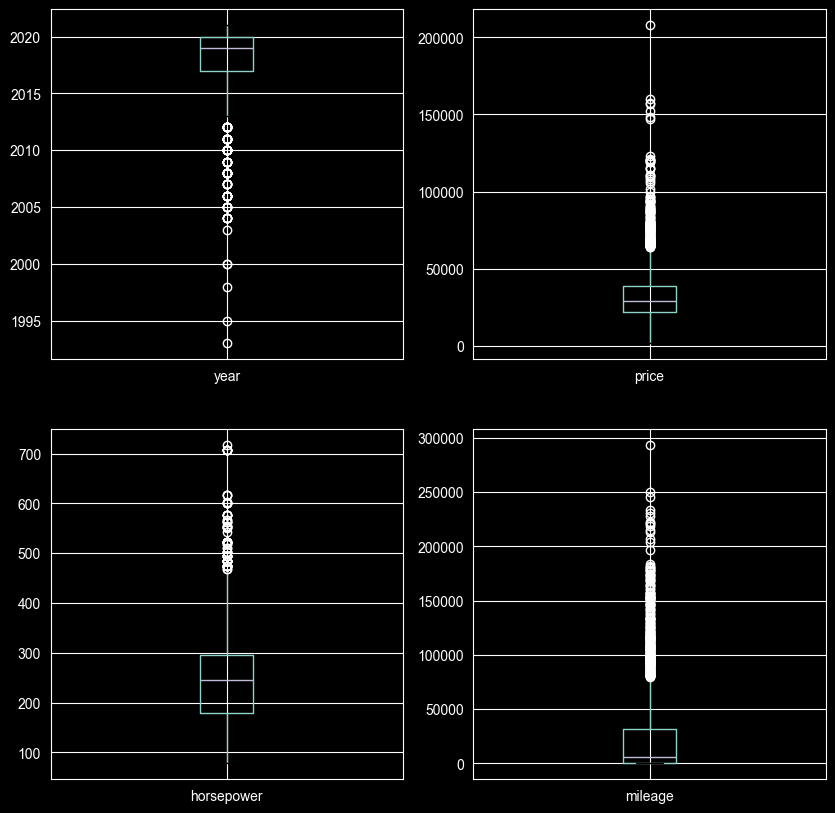

In [71]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

df_train.boxplot(column="year", ax=axes[0,0])
df_train.boxplot(column="price", ax=axes[0,1])
df_train.boxplot(column="horsepower", ax=axes[1,0])
df_train.boxplot(column="mileage", ax=axes[1,1])



Les boxplots permettent de mettre en lumière d'éventuels *outliers*, selon la règle de l'écart-interquartile.

- Il n'y a pas vraiment de raison de penser que les *outliers* sont dus à des erreurs, il s'agit plutôt de phénomènes rares mais plausibles.

#### <span style="color:#cc0000">Variables Catégorielles</span>




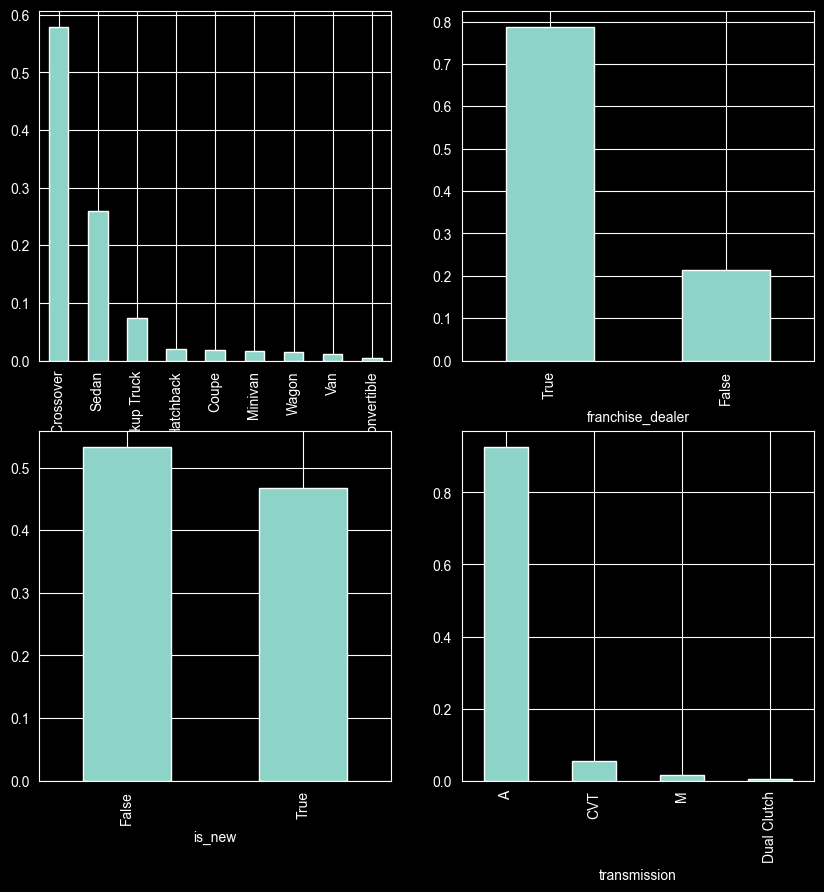

In [81]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

df_train["body_type"].value_counts(normalize=True).plot(kind='bar', ax=axes[0,0])
df_train["franchise_dealer"].value_counts(normalize=True).plot(kind='bar', ax=axes[0,1])
df_train["is_new"].value_counts(normalize=True).plot(kind='bar', ax=axes[1,0])
df_train["transmission"].value_counts(normalize=True).plot(kind='bar', ax=axes[1,1])




analyse à faire : .....

### <span style="color:#cc0000">Statistiques bivariées</span>


Les statistiques bivariées permettent de comprendre la structure des données, i.e. comment les différentes variables intéragissent entre eux. Dans notre cas, nous sommes particulièrement intéressés de voir comment la variable à prédire (`price`) est corrélée aux différentes variables à notre disposition. Cette étape doit permettre de **définir les variables pertinentes à inclure dans notre modélisation**.


### <span style="color:#cc0000">Prix selon le nombre de chevaux</span>


### <span style="color:#cc0000">Prix selon le nombre de chevaux</span>

    feature engineering : current_year = pd.Timestamp.now().year
    df["car_age"] = current_year - df["year"]